Libraries loaded
STEP 2: Loading and sampling 5,000 rows
  Full dataset: 99,958 rows
  Sampled: 5,000 rows
STEP 3: Fixing encoding
Done
STEP 4: Detecting languages
  Language breakdown:
lang
en    2029
fr    1528
de     345
es     273
it     185
nl     103
ca      96
pt      62
no      60
sv      58
pl      44
ro      37
et      33
af      25
sk      24
fi      21
hr      15
hu       9
da       8
id       7
tr       7
sq       5
lv       5
tl       5
sl       4
lt       4
cy       4
sw       3
cs       1
STEP 5: Translating to English
 Translating non-English rows...
    500/5000 rows done...
    1000/5000 rows done...
    1500/5000 rows done...
    2000/5000 rows done...
    2500/5000 rows done...
    3000/5000 rows done...
    3500/5000 rows done...
    4000/5000 rows done...
    4500/5000 rows done...
    5000/5000 rows done...
Translated 2547 rows
STEP 6: Building CTD lookup — auto matching
  Chemicals with disease links: 2,458
  Chemicals indexed with disease links: 2,458
  Total 

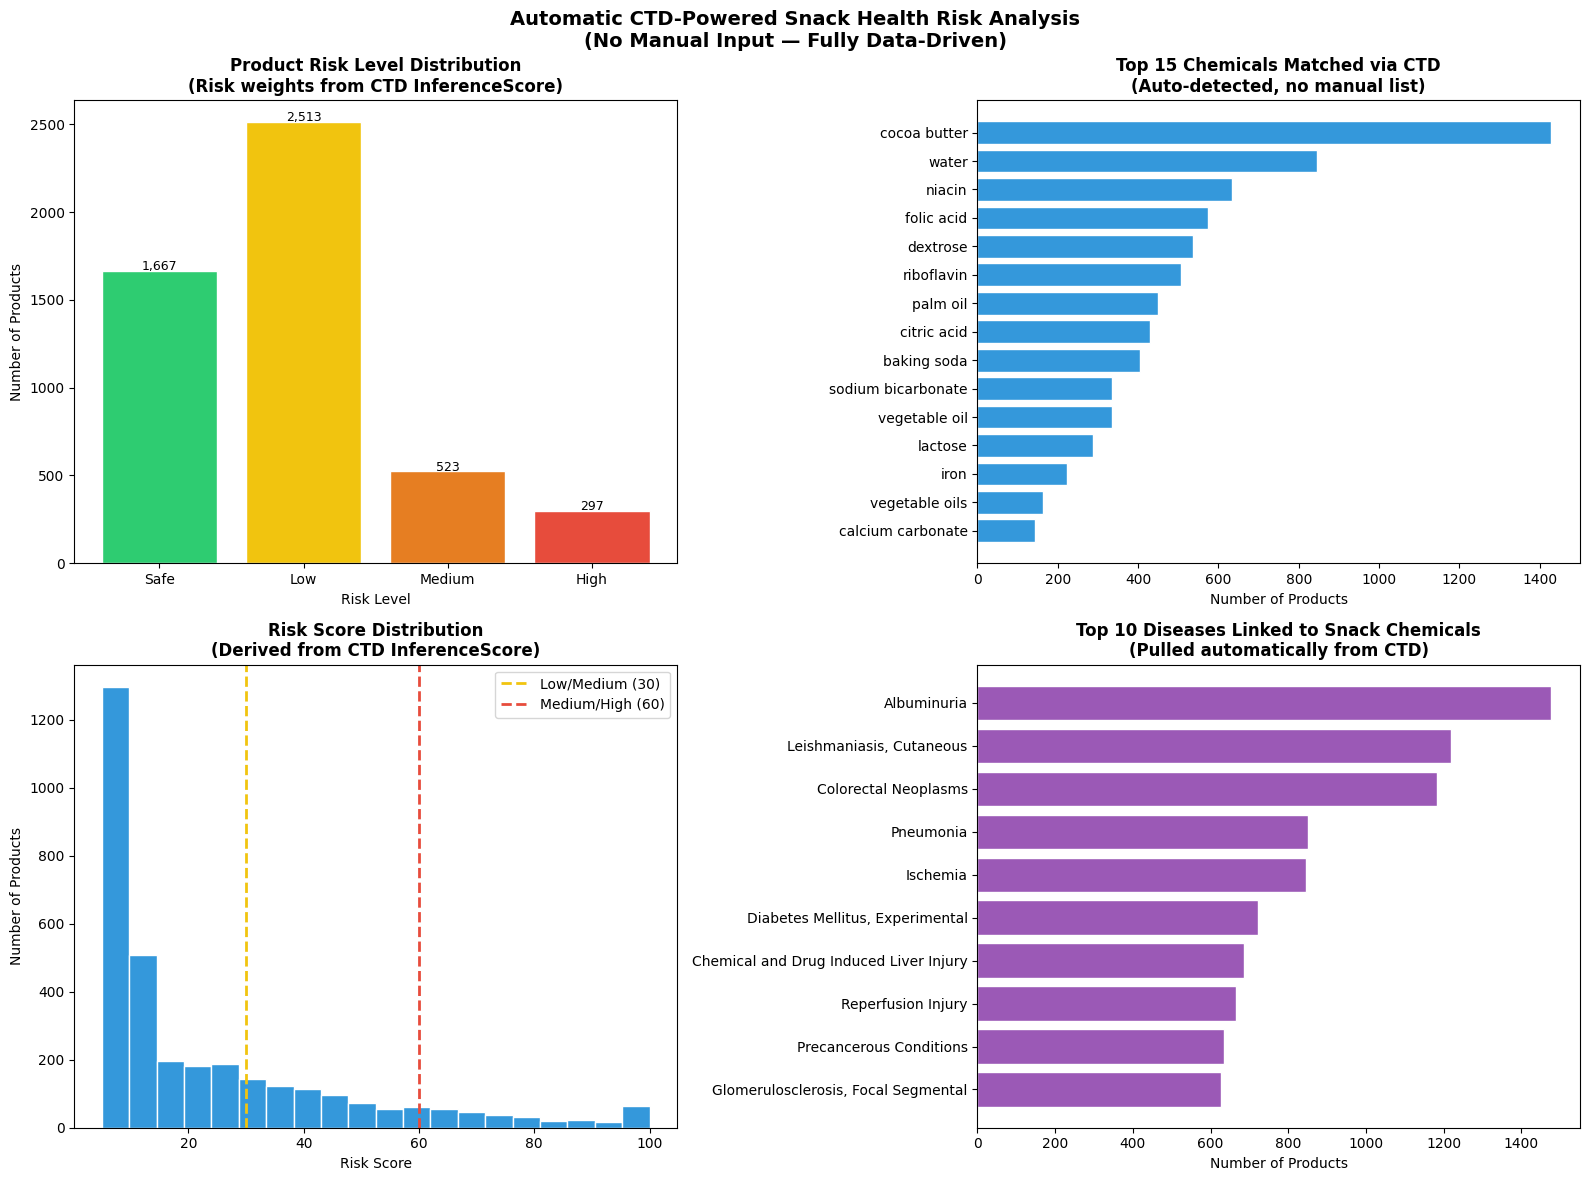

  ✓ Saved: ctd_auto_analysis.png


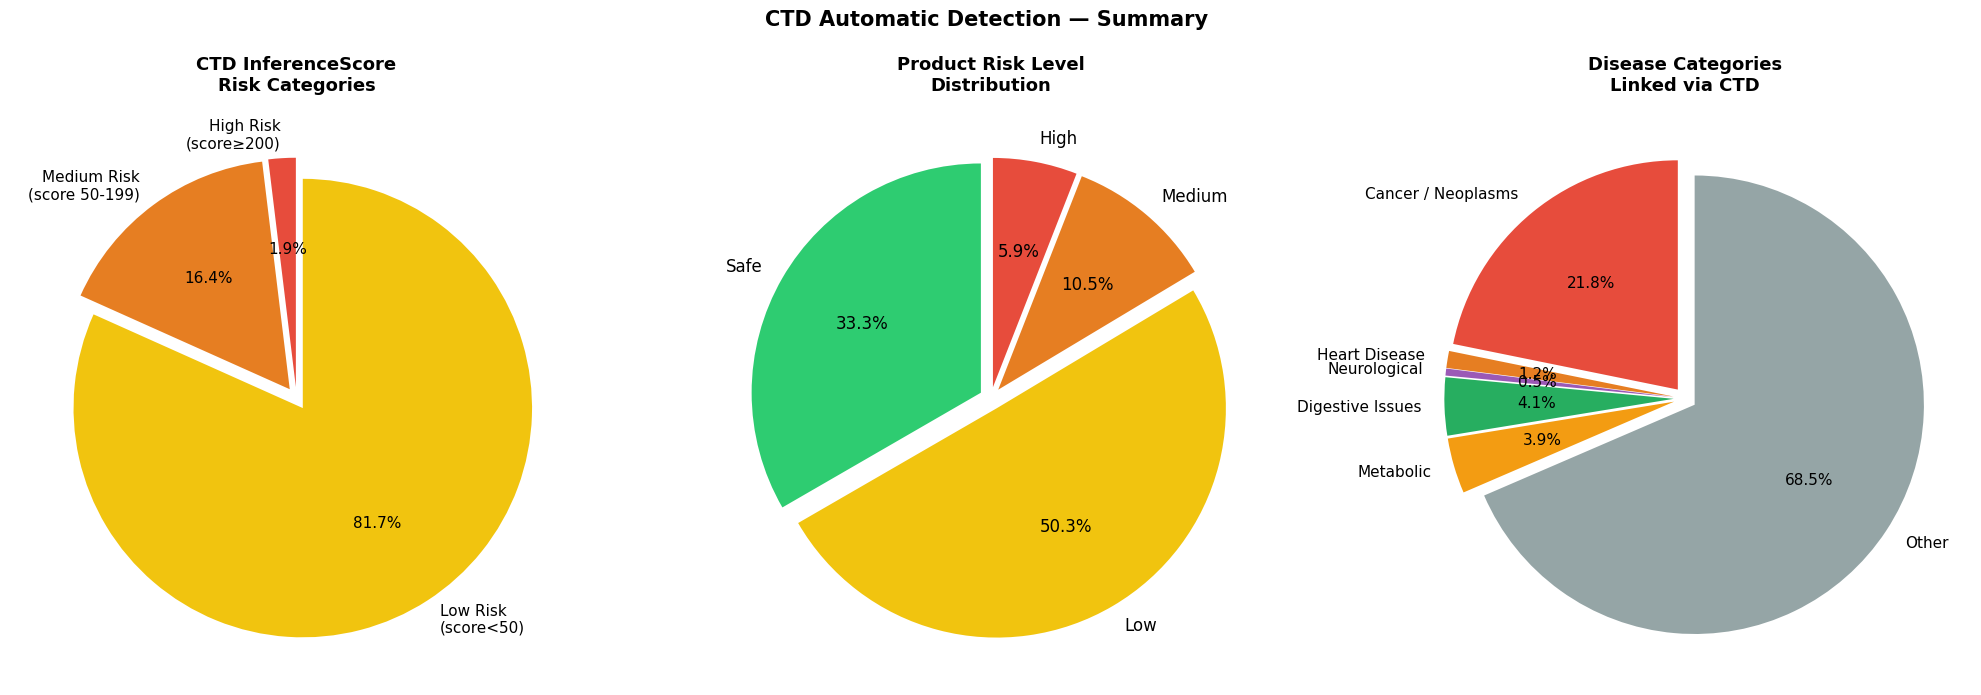

 Saved: ctd_pie_charts.png
STEP 12: Training ML model
  Train: 3,998 | Test: 1,000
  CV Mean: 0.954 (+/- 0.005)

  Model Accuracies:
    Logistic Regression       0.9510
    LDA                       0.9350
    KNN                       0.9470
    Random Forest             0.9730

  Tuning Random Forest...
  Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

  Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.80      0.85        59
         Low       0.98      1.00      0.99       503
      Medium       0.87      0.88      0.87       105
        Safe       1.00      1.00      1.00       333

    accuracy                           0.97      1000
   macro avg       0.94      0.92      0.93      1000
weighted avg       0.97      0.97      0.97      1000



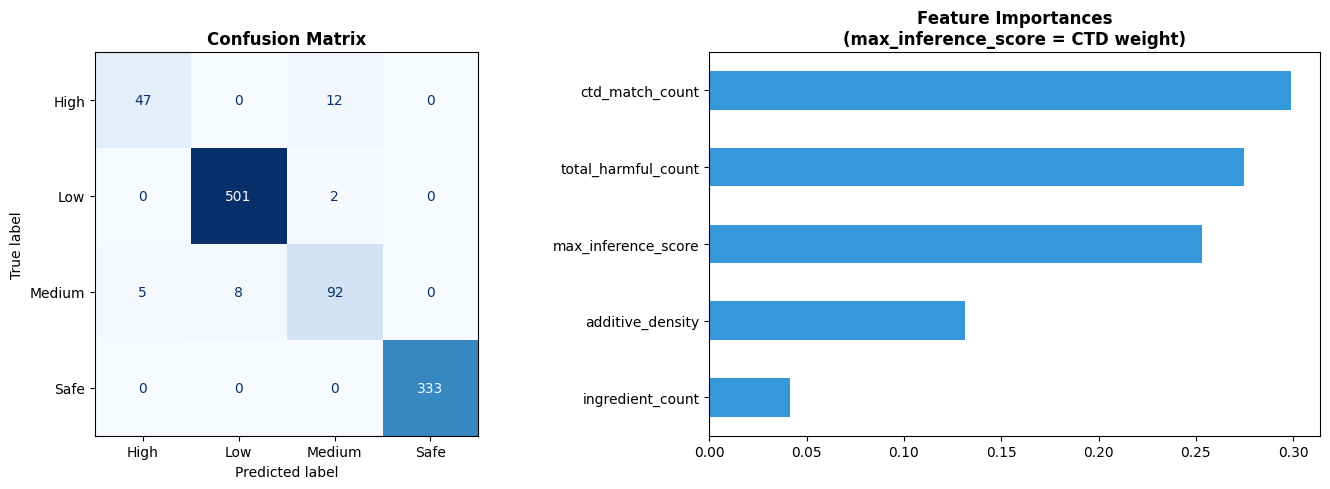

 Saved: model_evaluation.png
STEP 13: Saving results
  Saved: ctd_auto_results_5k.csv (4,998 rows)

  Top 10 Highest Risk Products:
                                                                                               product_name  risk_score risk_level                                                                                                                                                harmful_chemicals                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [ ]:

# STEP 0 — INSTALL
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "scikit-learn",
                "matplotlib", "langdetect", "ftfy",
                "deep-translator", "-q"])


# STEP 1 — IMPORTS
import pandas as pd
import numpy as np
import re
import time
import warnings
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
print("Libraries loaded")

# STEP 2 — LOAD & SAMPLE 5,000 ROWS

print("STEP 2: Loading and sampling 5,000 rows")

df = pd.read_csv("snacks_cleaned.csv")
if "ingredients_text" in df.columns:
    df = df.drop(columns=["ingredients_text"])
df = df.dropna(subset=["ingredients_cleaned"])
print(f"  Full dataset: {len(df):,} rows")

df = df.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"  Sampled: {len(df):,} rows")

# STEP 3 — FIX ENCODING
print("STEP 3: Fixing encoding")

from ftfy import fix_text
df["ingredients_clean"] = df["ingredients_cleaned"].apply(lambda x: fix_text(str(x)))
print("Done")


# STEP 4 — DETECT LANGUAGE
print("STEP 4: Detecting languages")

from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def detect_lang(text):
    try:
        return detect(str(text)[:300])
    except:
        return "en"

df["lang"] = df["ingredients_clean"].apply(detect_lang)
print("  Language breakdown:")
print(df["lang"].value_counts().to_string())

# STEP 5 — TRANSLATE

print("STEP 5: Translating to English")

from deep_translator import GoogleTranslator

SUPPORTED = {"fr", "de", "es", "pt", "it", "nl", "pl", "ar", "ru", "tr"}

def translate_to_english(text, lang_code):
    if lang_code == "en" or lang_code not in SUPPORTED:
        return text
    try:
        result = GoogleTranslator(
            source=lang_code, target="en"
        ).translate(str(text)[:4500])
        return result if result else text
    except:
        return text

print(" Translating non-English rows...")
ingredients_english = []
translated_count = 0

for i, row in df.iterrows():
    if row["lang"] != "en" and row["lang"] in SUPPORTED:
        translated = translate_to_english(row["ingredients_clean"], row["lang"])
        ingredients_english.append(translated)
        translated_count += 1
    else:
        ingredients_english.append(row["ingredients_clean"])

    if (i + 1) % 500 == 0:
        print(f"    {i+1}/{len(df)} rows done...")
    if (i + 1) % 100 == 0:
        time.sleep(0.5)

df["ingredients_english"] = ingredients_english
print(f"Translated {translated_count} rows")

# STEP 6 — BUILD CTD LOOKUP (FIX ID MISMATCH)
print("STEP 6: Building CTD lookup — auto matching")


# Load CTD chemicals
df_chem = pd.read_csv("ctd_chemicals_sample.csv")
df_chem.columns = df_chem.columns.str.strip()
df_chem = df_chem.rename(columns={"# ChemicalName": "ChemicalName"})

# Load CTD diseases
df_dis = pd.read_csv("ctd_sample.csv", header=None,
                     names=["ChemicalName","ChemicalID","CasRN","DiseaseName",
                            "DiseaseID","DirectEvidence","GeneSymbol",
                            "InferenceScore","OmimIDs","PubMedIDs"])
df_dis = df_dis[df_dis["ChemicalID"] != "ChemicalID"].copy()
df_dis["InferenceScore"] = pd.to_numeric(
    df_dis["InferenceScore"], errors="coerce").fillna(1.0)

# FIX: Strip "MESH:" prefix from chemicals file to match disease file
df_chem["ChemicalID_clean"] = df_chem["ChemicalID"].str.replace(
    "MESH:", "", regex=False).str.strip()

# Build ChemicalID : diseases lookup
id_to_diseases = defaultdict(list)
for _, row in df_dis.iterrows():
    chem_id = str(row["ChemicalID"]).strip()
    disease = str(row["DiseaseName"]).strip()
    score = float(row["InferenceScore"])
    id_to_diseases[chem_id].append((disease, score))

chemicals_with_diseases = set(id_to_diseases.keys())
print(f"  Chemicals with disease links: {len(chemicals_with_diseases):,}")

# Build synonym : ChemicalID (only for chemicals that HAVE disease links)
synonym_to_id = {}
matched_chem_count = 0

for _, row in df_chem.iterrows():
    chem_id_clean = str(row["ChemicalID_clean"]).strip()

    # Only index if this chemical has disease links
    if chem_id_clean not in chemicals_with_diseases:
        continue

    matched_chem_count += 1

    # Add main name
    name = str(row["ChemicalName"]).strip().lower()
    if len(name) > 3:
        synonym_to_id[name] = chem_id_clean

    # Add MeSH synonyms
    if pd.notna(row.get("MESHSynonyms")):
        for syn in str(row["MESHSynonyms"]).split("|"):
            s = syn.strip().lower()
            if len(s) > 3:
                synonym_to_id[s] = chem_id_clean

    # Add CTD curated synonyms
    if pd.notna(row.get("CTDCuratedSynonyms")):
        for syn in str(row["CTDCuratedSynonyms"]).split("|"):
            s = syn.strip().lower()
            if len(s) > 3:
                synonym_to_id[s] = chem_id_clean

print(f"  Chemicals indexed with disease links: {matched_chem_count:,}")
print(f"  Total synonyms indexed: {len(synonym_to_id):,}")

# Verify fix worked
test_matches = 0
for syn, cid in list(synonym_to_id.items())[:100]:
    if cid in id_to_diseases:
        test_matches += 1
print(f" Verification — synonyms linking to diseases: {test_matches}/100 ")


# STEP 7 — EXTRACT ALL UNIQUE INGREDIENT TOKENS FROM DATASET

print("STEP 7: Extracting ingredient tokens from dataset")

all_tokens = set()
for text in df["ingredients_english"]:
    tokens = [t.strip().lower() for t in
              re.split(r"[,;\n\(\)]", str(text)) if len(t.strip()) > 3]
    all_tokens.update(tokens)

print(f"  Unique ingredient tokens found: {len(all_tokens):,}")

# Find which tokens match CTD
ctd_matched_tokens = {t: synonym_to_id[t] for t in all_tokens if t in synonym_to_id}
print(f"  Tokens matched in CTD: {len(ctd_matched_tokens):,}")
print(f"  Coverage: {100*len(ctd_matched_tokens)/len(all_tokens):.2f}%")

if ctd_matched_tokens:
    print(f"\n  Matched chemicals:")
    for token, cid in list(ctd_matched_tokens.items())[:20]:
        diseases = [d for d, _ in id_to_diseases.get(cid, [])][:2]
        print(f"    {token:<35} → {', '.join(diseases)}")


# STEP 8 — FULLY AUTOMATIC SCANNING (CTD ONLY)

print("STEP 8: Scanning ingredients — fully automatic from CTD")

def scan_automatic(text):

    text_lower = str(text).lower()
    found = []
    seen = set()

    tokens = [t.strip() for t in
              re.split(r"[,;\n\(\)]", text_lower) if len(t.strip()) > 3]

    for token in tokens:
        if token in seen:
            continue
        if token in synonym_to_id:
            chem_id = synonym_to_id[token]
            if chem_id in id_to_diseases:
                diseases_scores = id_to_diseases[chem_id]

                # Use CTD InferenceScore as risk weight
                # Normalize: score 0-50 → weight 1-10
                #            score 50-200 → weight 10-20
                #            score 200+ → weight 20-25
                max_score = max(s for _, s in diseases_scores)
                if max_score >= 200:
                    weight = 25
                elif max_score >= 100:
                    weight = 20
                elif max_score >= 50:
                    weight = 15
                elif max_score >= 20:
                    weight = 10
                else:
                    weight = 5

                diseases = list(set(d for d, _ in diseases_scores))[:5]

                found.append({
                    "chemical": token,
                    "chem_id": chem_id,
                    "diseases": diseases,
                    "weight": weight,
                    "inference_score": max_score,
                    "source": "CTD_AUTO"
                })
                seen.add(token)

    return found

print("  Scanning 5,000 rows automatically...")
df["detected"] = df["ingredients_english"].apply(scan_automatic)
df["total_harmful_count"] = df["detected"].apply(len)
df["ctd_match_count"] = df["detected"].apply(len)
df["harmful_chemicals"] = df["detected"].apply(
    lambda d: [x["chemical"] for x in d])
df["health_risks"] = df["detected"].apply(
    lambda d: list(set(dis for x in d for dis in x["diseases"])))
df["max_inference_score"] = df["detected"].apply(
    lambda d: max([x["inference_score"] for x in d]) if d else 0)

found = (df["total_harmful_count"] > 0).sum()
print(f"  ✓ Products with CTD matches: {found:,} ({100*found/len(df):.1f}%)")
print(f"  Total CTD chemical matches: {df['ctd_match_count'].sum():,}")

# STEP 9 — RISK SCORE FROM CTD INFERENCE SCORES


print("STEP 9: Calculating risk scores from CTD InferenceScores")

df["risk_score"] = df["detected"].apply(
    lambda d: min(sum(x["weight"] for x in d), 100))
df["risk_level"] = df["risk_score"].apply(
    lambda s: "Safe" if s == 0
    else "Low" if s <= 30
    else "Medium" if s <= 60
    else "High")

print("  Risk Level Distribution:")
print(df["risk_level"].value_counts().to_string())
print(f"\n  Risk Score Stats:")
print(df["risk_score"].describe().round(2).to_string())


# STEP 10 — DISEASE SUMMARY

print("STEP 10: Disease summary from CTD")


all_diseases = []
for d in df["health_risks"]:
    all_diseases.extend(d)
disease_counts = Counter(all_diseases)

print(f"  Total unique diseases identified: {len(disease_counts):,}")
print(f"  Top 10 diseases (all from CTD — no manual input):")
for disease, count in disease_counts.most_common(10):
    print(f"    {disease:<45} {count:,} products")


# STEP 11 — VISUALIZATIONS
print("\n" + "=" * 60)
print("STEP 11: Visualizations")
print("=" * 60)

all_chems = []
for c in df["harmful_chemicals"]:
    all_chems.extend(c)
chem_counts = Counter(all_chems)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Automatic CTD-Powered Snack Health Risk Analysis\n(No Manual Input — Fully Data-Driven)",
             fontsize=14, fontweight="bold")

# Chart 1 — Risk level
risk_order = ["Safe", "Low", "Medium", "High"]
risk_counts = df["risk_level"].value_counts().reindex(risk_order, fill_value=0)
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
bars = axes[0, 0].bar(risk_counts.index, risk_counts.values,
                       color=colors, edgecolor="white")
axes[0, 0].set_title("Product Risk Level Distribution\n(Risk weights from CTD InferenceScore)",
                      fontweight="bold")
axes[0, 0].set_xlabel("Risk Level")
axes[0, 0].set_ylabel("Number of Products")
for bar, val in zip(bars, risk_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 5, f"{val:,}", ha="center", fontsize=9)

# Chart 2 — Top chemicals matched via CTD
top_chems = chem_counts.most_common(15)
if top_chems:
    axes[0, 1].barh([c[0] for c in top_chems][::-1],
                    [c[1] for c in top_chems][::-1],
                    color="#3498db", edgecolor="white")
axes[0, 1].set_title("Top 15 Chemicals Matched via CTD\n(Auto-detected, no manual list)",
                      fontweight="bold")
axes[0, 1].set_xlabel("Number of Products")

# Chart 3 — Risk score distribution
nonzero = df[df["risk_score"] > 0]["risk_score"]
if len(nonzero) > 0:
    axes[1, 0].hist(nonzero, bins=20, color="#3498db", edgecolor="white")
    axes[1, 0].axvline(30, color="#f1c40f", linestyle="--",
                       linewidth=2, label="Low/Medium (30)")
    axes[1, 0].axvline(60, color="#e74c3c", linestyle="--",
                       linewidth=2, label="Medium/High (60)")
    axes[1, 0].legend()
axes[1, 0].set_title("Risk Score Distribution\n(Derived from CTD InferenceScore)",
                      fontweight="bold")
axes[1, 0].set_xlabel("Risk Score")
axes[1, 0].set_ylabel("Number of Products")

# Chart 4 — Top diseases from CTD
top_diseases = disease_counts.most_common(10)
if top_diseases:
    axes[1, 1].barh([d[0] for d in top_diseases][::-1],
                    [d[1] for d in top_diseases][::-1],
                    color="#9b59b6", edgecolor="white")
axes[1, 1].set_title("Top 10 Diseases Linked to Snack Chemicals\n(Pulled automatically from CTD)",
                      fontweight="bold")
axes[1, 1].set_xlabel("Number of Products")

plt.tight_layout()
plt.savefig("ctd_auto_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: ctd_auto_analysis.png")

# ── 3 PIE CHARTS ──
fig2, axes2 = plt.subplots(1, 3, figsize=(20, 7))
fig2.suptitle("CTD Automatic Detection — Summary",
              fontsize=15, fontweight="bold", y=1.02)

# Pie 1 — Harmful ingredient categories (auto-detected from CTD)
ctd_chemical_list = list(chem_counts.keys())
category_counts = {
    "High Risk\n(score≥200)": sum(1 for c in df["detected"].explode()
                                   if isinstance(c, dict) and c.get("inference_score", 0) >= 200),
    "Medium Risk\n(score 50-199)": sum(1 for c in df["detected"].explode()
                                        if isinstance(c, dict) and 50 <= c.get("inference_score", 0) < 200),
    "Low Risk\n(score<50)": sum(1 for c in df["detected"].explode()
                                 if isinstance(c, dict) and 0 < c.get("inference_score", 0) < 50),
}
category_counts = {k: v for k, v in category_counts.items() if v > 0}
if category_counts:
    axes2[0].pie(
        list(category_counts.values()),
        labels=list(category_counts.keys()),
        colors=["#e74c3c", "#e67e22", "#f1c40f"],
        autopct="%1.1f%%",
        startangle=90,
        explode=[0.05] * len(category_counts),
        textprops={"fontsize": 11}
    )
axes2[0].set_title("CTD InferenceScore\nRisk Categories",
                    fontweight="bold", fontsize=13, pad=15)

# Pie 2 — Risk level distribution
risk_nonzero = risk_counts[risk_counts > 0]
axes2[1].pie(
    risk_nonzero.values,
    labels=risk_nonzero.index,
    colors=["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"][:len(risk_nonzero)],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(risk_nonzero),
    textprops={"fontsize": 12}
)
axes2[1].set_title("Product Risk Level\nDistribution",
                    fontweight="bold", fontsize=13, pad=15)

# Pie 3 — Disease categories from CTD
disease_categories = {
    "Cancer / Neoplasms": 0,
    "Heart Disease": 0,
    "Neurological": 0,
    "Digestive Issues": 0,
    "Metabolic": 0,
    "Other": 0,
}
for disease, count in disease_counts.items():
    d = disease.lower()
    if any(w in d for w in ["cancer", "neoplas", "tumor", "carcinoma", "leukemia"]):
        disease_categories["Cancer / Neoplasms"] += count
    elif any(w in d for w in ["heart", "cardio", "stroke", "coronary", "atherosclerosis"]):
        disease_categories["Heart Disease"] += count
    elif any(w in d for w in ["neuro", "headach", "brain", "adhd", "alzheimer", "parkinson"]):
        disease_categories["Neurological"] += count
    elif any(w in d for w in ["digest", "gut", "bowel", "colon", "gastro", "liver"]):
        disease_categories["Digestive Issues"] += count
    elif any(w in d for w in ["obes", "metabol", "diabet", "insulin"]):
        disease_categories["Metabolic"] += count
    else:
        disease_categories["Other"] += count

disease_categories = {k: v for k, v in disease_categories.items() if v > 0}
if disease_categories:
    axes2[2].pie(
        list(disease_categories.values()),
        labels=list(disease_categories.keys()),
        colors=["#e74c3c", "#e67e22", "#9b59b6", "#27ae60", "#f39c12", "#95a5a6"],
        autopct="%1.1f%%",
        startangle=90,
        explode=[0.05] * len(disease_categories),
        textprops={"fontsize": 11}
    )
axes2[2].set_title("Disease Categories\nLinked via CTD",
                    fontweight="bold", fontsize=13, pad=15)

plt.tight_layout()
plt.savefig("ctd_pie_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: ctd_pie_charts.png")


# STEP 12 — ML MODEL

print("STEP 12: Training ML model")

df["ingredient_count"] = df["ingredients_english"].apply(
    lambda t: len(re.split(r"[,;\n]", str(t))))
df["additive_density"] = df["total_harmful_count"] / (df["ingredient_count"] + 1)
df = df[df["ingredient_count"] < 200]

feature_cols = ["total_harmful_count", "ctd_match_count",
                "ingredient_count", "additive_density", "max_inference_score"]

X = df[feature_cols]
y = df["risk_level"]
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print(f"  Train: {len(X_train):,} | Test: {len(X_test):,}")

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_train, y_train, cv=5)
print(f"  CV Mean: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "LDA":                 LinearDiscriminantAnalysis(),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Random Forest":       RandomForestClassifier(
        random_state=42, class_weight="balanced", n_jobs=-1)
}
print("\n  Model Accuracies:")
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"    {name:<25} {model.score(X_test, y_test):.4f}")

print("\n  Tuning Random Forest...")
param_grid = {"n_estimators": [50, 100],
              "max_depth": [None, 10],
              "min_samples_split": [2, 5]}
rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
grid = GridSearchCV(rf, param_grid, cv=3, scoring="f1_weighted", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"  Best params: {grid.best_params_}")

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=le.classes_).plot(ax=axes3[0], colorbar=False, cmap="Blues")
axes3[0].set_title("Confusion Matrix", fontweight="bold")
pd.Series(best_model.feature_importances_,
          index=feature_cols).sort_values().plot(
    kind="barh", ax=axes3[1], color="#3498db")
axes3[1].set_title("Feature Importances\n(max_inference_score = CTD weight)",
                    fontweight="bold")
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: model_evaluation.png")

df["predicted_risk_level"] = le.inverse_transform(best_model.predict(X))


# STEP 13 — SAVE

print("STEP 13: Saving results")

df["harmful_chemicals"] = df["harmful_chemicals"].apply(
    lambda x: ", ".join(x) if x else "none")
df["health_risks"] = df["health_risks"].apply(
    lambda x: ", ".join(x) if x else "none")

output_cols = [c for c in [
    "product_name", "categories_en", "ingredients_cleaned",
    "ingredients_english", "lang",
    "harmful_chemicals", "total_harmful_count", "ctd_match_count",
    "max_inference_score", "ingredient_count", "additive_density",
    "risk_score", "risk_level", "predicted_risk_level", "health_risks"
] if c in df.columns]

df[output_cols].to_csv("ctd_auto_results_5k.csv", index=False)
print(f"  Saved: ctd_auto_results_5k.csv ({len(df):,} rows)")

print("\n  Top 10 Highest Risk Products:")
print(df.nlargest(10, "risk_score")[
    [c for c in ["product_name", "risk_score", "risk_level",
                 "harmful_chemicals", "health_risks"] if c in df.columns]
].to_string())

print("\nPIPELINE COMPLETE — 100% automatic from CTD!")
print("  No manual chemical list used")
print("  No manual disease list used")
print("  Risk weights derived from CTD InferenceScore")
print("\nOutput files:")
print("  - ctd_auto_results_5k.csv")
print("  - ctd_auto_analysis.png")
print("  - ctd_pie_charts.png")
print("  - model_evaluation.png")